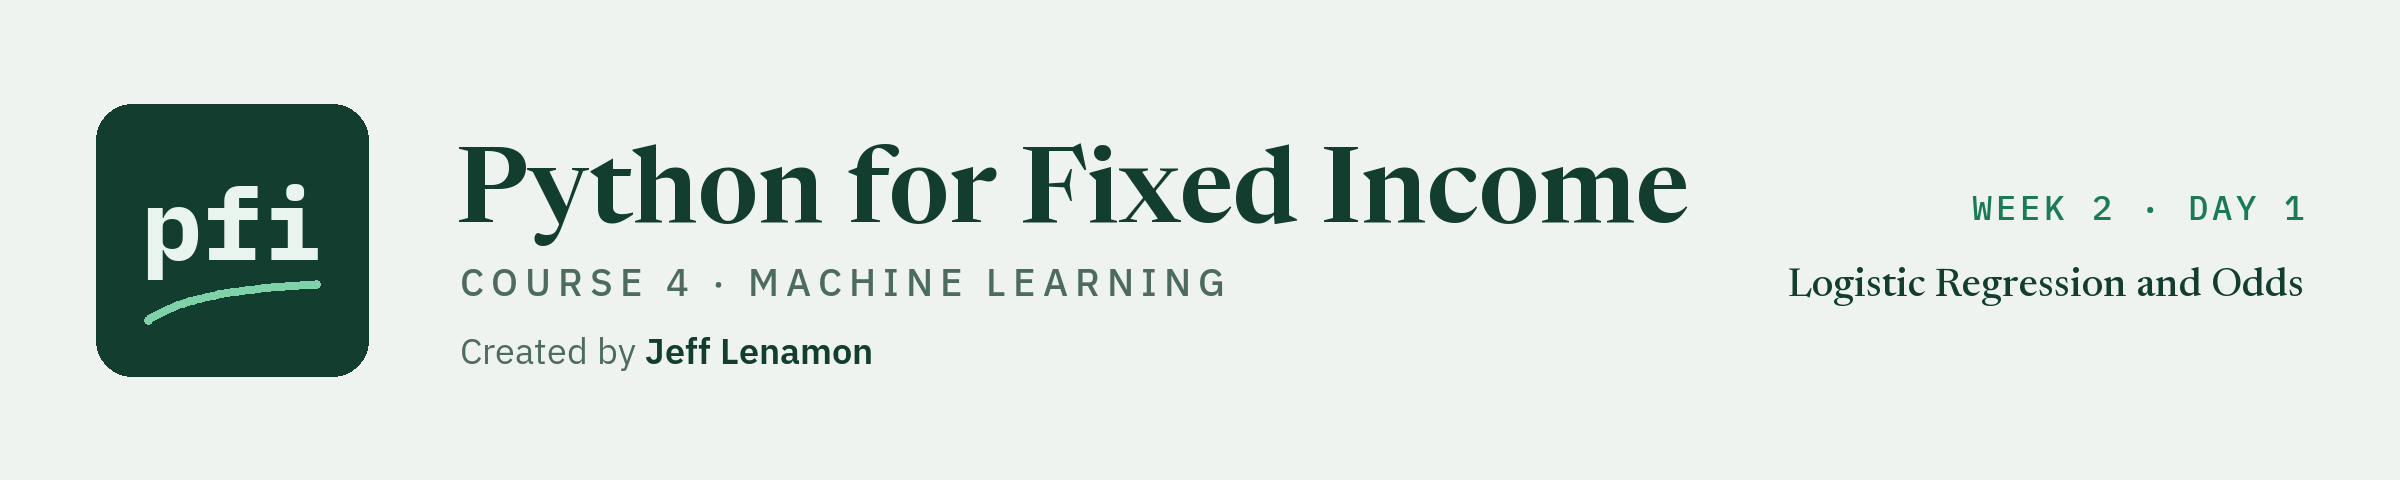

# Logistic Regression and Odds

Week 2, Day 1. A probability needs a curve, not a straight line. Today: probability, odds, and log odds; a logistic regression fitted with statsmodels and with scikit-learn; and a coefficient read as an odds ratio, with its unit.

**Data:** `credit_card_default.csv`, 30,000 card accounts in Taiwan in 2005: **real**, UCI Machine Learning Repository dataset 350, CC BY 4.0. Citation: Yeh, I. (2009). Default of Credit Card Clients [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course4_machine_learning/week2/day1/06_logistic_regression_and_odds.ipynb)

Week 1 fitted spreads, numbers that can take any value. Week 2 fits an outcome that is 0 or 1: whether a credit card account defaulted the following month. Course 1, notebook 16, described this file with rates and counts and fitted no model. This week models it.

**The data is real, and it describes people.** The 30,000 accounts are in Taiwan, with payment records from April to September 2005. Consumer credit there and then differs from US credit, so nothing this week carries over to another market or another year. The file is the UCI dataset cited above, unchanged.

**Four columns are never model features: `SEX`, `EDUCATION`, `MARRIAGE`, and `AGE`.** The course describes a file and builds no lending rule. A model that used these columns would sort people by them. And leaving them out does not make a model neutral, because other columns can carry the same information. Every model this week uses the other 19 columns.

**What a model on this file is called.** Its output is the *model probability of default in this file*, or, from day 7, *flagged at threshold t*. It is never a credit decision, an approval, a decline, a lending policy, or a risk grade for a real person. An odds ratio is an association in these accounts, not a cause.

**The week's split.** The accounts are split once, today, into 60 percent training rows, 20 percent validation rows, and 20 percent test rows. Days 6 to 9 fit on training rows and report on validation rows. The test rows are opened once, on day 10.

Today you will:

1. Load the card file, name the 19 features, and make the week's split, with a no-leak check on every pair.
2. See why a straight line fails on a 0/1 outcome.
3. Draw the logistic curve, which turns any number into a probability.
4. Move between probability, odds, and log odds, and add `logistic_probability` and `odds_ratios` to `mlkit.py`.
5. Fit a logistic regression with statsmodels and read each coefficient as an odds ratio, with its unit.
6. Fit the same model with scikit-learn: the default penalty, `C=np.inf`, and a `Pipeline`.
7. Fit all 19 columns, scaled, and read coefficients per standard deviation.
8. Say what the model's probability is, and what it is not.

Q. Set up today's work folder: the thread settings, the seed, and today's four data files.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, or scikit-learn is imported: if you ran another cell first,
# restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# four packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("pytest", "pytest")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course4_machine_learning/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "statsmodels": "0.15.0", "scipy": "1.18.1", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "benchmark.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course4_06_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["benchmark.csv", "ratings.csv", "course4_excel_reference.csv", "credit_card_default.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, statsmodels 0.15.0, scipy 1.18.1, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course4_06_vgb0r11l, in your temp folder
Data files from the data folder of the course repo: benchmark.csv, ratings.csv, course4_excel_reference.csv, credit_card_default.csv
SEED = 42


Q. Write `mlkit.py` and `test_mlkit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")

Writing mlkit.py


In [3]:
%%writefile test_mlkit.py
"""Tests for mlkit.py.

Expected values come from Excel (course4_excel_reference.csv in this folder), from scikit-learn or statsmodels on
the same inputs, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

import mlkit

HERE = Path(__file__).resolve().parent
SEED = 42


def read_bench() -> pd.DataFrame:
    """The 821 synthetic benchmark bonds joined to their rating score, with log_oas (natural log of bp)."""
    bench = pd.read_csv(HERE / "benchmark.csv")
    ratings = pd.read_csv(HERE / "ratings.csv")
    bench = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    bench["log_oas"] = np.log(bench["oas"])
    return bench


def excel(case_id: str) -> float:
    """One value computed by Excel, looked up by its case_id (model:quantity)."""
    reference = pd.read_csv(HERE / "course4_excel_reference.csv", float_precision="round_trip")
    return float(reference.set_index("case_id").loc[case_id, "excel_value"])


def test_assert_disjoint_passes():
    mlkit.assert_disjoint([0, 1, 2], [3, 4])


def test_assert_disjoint_raises_with_count():
    with pytest.raises(AssertionError, match="2 row labels"):
        mlkit.assert_disjoint([0, 1, 2, 3], [2, 3, 4])


def test_regression_metrics_hand_values():
    # errors 10, -10, 30 bp around a mean of 200 bp
    metrics = mlkit.regression_metrics([100.0, 200.0, 300.0], [110.0, 190.0, 330.0])
    assert metrics["mae"] == pytest.approx(50 / 3, abs=1e-12)
    assert metrics["rmse"] == pytest.approx(np.sqrt(1100 / 3), abs=1e-12)
    # SS_res 1,100 over SS_tot 20,000
    assert metrics["r2"] == pytest.approx(1 - 1100 / 20000, abs=1e-12)


def test_regression_metrics_match_sklearn():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(r2_score(bench["oas"], fitted), abs=1e-12)
    assert metrics["mae"] == pytest.approx(mean_absolute_error(bench["oas"], fitted), abs=1e-12)
    assert metrics["rmse"] == pytest.approx(root_mean_squared_error(bench["oas"], fitted), abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.regression_metrics([1.0, 2.0], [1.0])


def test_slope_matches_excel_reference():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    # Excel: =SLOPE(oas, score), =INTERCEPT(oas, score), =RSQ(oas, score) over the 821 bonds
    assert slope == pytest.approx(excel("d01_oas_on_score:slope"), abs=1e-9)
    assert intercept == pytest.approx(excel("d01_oas_on_score:intercept"), abs=1e-9)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(excel("d01_oas_on_score:rsq"), abs=1e-9)
    # Excel: =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)), in bp
    assert metrics["mae"] == pytest.approx(excel("d01_oas_on_score:mae_bp"), abs=1e-9)
    assert metrics["rmse"] == pytest.approx(excel("d01_oas_on_score:rmse_bp"), abs=1e-9)


import statsmodels.api as sm


def rating_levels() -> list[str]:
    """Every rating level, AAA to CCC, in the order of ratings.csv."""
    return pd.read_csv(HERE / "ratings.csv")["rating"].tolist()


def sector_dummies(sectors: pd.Series, reference: str = "Consumer") -> pd.DataFrame:
    """One float column per sector except the reference, named sector_<name>, in alphabetical order."""
    return pd.DataFrame({f"sector_{s}": (sectors == s).astype(float) for s in sorted(sectors.unique())
                         if s != reference}, index=sectors.index)


def test_adjusted_r2_hand_value():
    # 1 - (1 - 0.8) x 99 / 96
    assert mlkit.adjusted_r2(0.8, 100, 3) == pytest.approx(1 - 0.2 * 99 / 96, abs=1e-12)


def test_adjusted_r2_rejects_too_few_rows():
    with pytest.raises(ValueError):
        mlkit.adjusted_r2(0.8, 4, 3)


def test_rating_dummies_reference_absent():
    ratings = pd.Series(["AAA", "A", "BBB", "A"])
    dummies = mlkit.rating_dummies(ratings, ["AAA", "A", "BBB"], reference="A")
    assert list(dummies.columns) == ["rating_AAA", "rating_BBB"]
    # an A-rated bond has every indicator at 0.0: the intercept stands for it
    assert dummies.loc[1].tolist() == [0.0, 0.0]
    assert dummies.dtypes.eq(float).all()


def test_rating_dummies_unknown_level_raises():
    with pytest.raises(ValueError, match="BB"):
        mlkit.rating_dummies(pd.Series(["AAA", "BB"]), ["AAA", "A"], reference="A")
    with pytest.raises(ValueError):
        mlkit.rating_dummies(pd.Series(["AAA"]), ["AAA", "A"], reference="CCC")


def test_linest_multi_matches_excel_reference():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["oas"], sm.add_constant(X)).fit()
    model = "d02_oas_on_rating_duration_sector"
    # Excel's LINEST reverses the columns; the reference file names each value in statsmodels' order
    for name in ["const"] + list(X.columns):
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
    assert fit.rsquared == pytest.approx(excel(f"{model}:r2"), abs=1e-9)
    assert fit.df_resid == excel(f"{model}:df_resid")
    assert fit.fvalue == pytest.approx(excel(f"{model}:f"), rel=1e-9)
    adjusted = mlkit.adjusted_r2(fit.rsquared, len(X), X.shape[1])
    assert adjusted == pytest.approx(excel(f"{model}:adj_r2"), abs=1e-9)
    assert adjusted == pytest.approx(fit.rsquared_adj, abs=1e-12)


from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor


def m3_features(bench: pd.DataFrame) -> pd.DataFrame:
    """Rating score, duration, and the nine sector dummies (reference Consumer): the day 3 inference model."""
    return pd.concat([bench[["score", "duration"]], sector_dummies(bench["sector"])], axis=1)


def test_vif_matches_statsmodels():
    X = m3_features(read_bench())
    vifs = mlkit.vif_table(X)
    with_constant = sm.add_constant(X).to_numpy()
    for j, name in enumerate(X.columns, start=1):
        assert vifs[name] == pytest.approx(variance_inflation_factor(with_constant, j), abs=1e-9), name
    # sorted from the highest VIF down
    assert vifs.is_monotonic_decreasing


def test_vif_matches_excel_reference():
    vifs = mlkit.vif_table(m3_features(read_bench()))
    for name, value in vifs.items():
        # Excel: =1/(1-INDEX(LINEST(xj, the other columns, TRUE, TRUE), 3, 1))
        assert value == pytest.approx(excel(f"d03_vif:vif_{name}"), abs=1e-9), name


def test_vif_perfect_collinearity_is_huge():
    bench = read_bench()
    # spread_duration equals duration on every bond of the file
    vifs = mlkit.vif_table(bench[["score", "duration", "spread_duration"]])
    assert vifs["duration"] > 1e10
    assert vifs["spread_duration"] > 1e10
    assert vifs["score"] < 5


def test_ols_matches_sklearn():
    bench = read_bench()
    X = m3_features(bench)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    linear = LinearRegression().fit(X, bench["log_oas"])
    assert linear.intercept_ == pytest.approx(fit.params["const"], abs=1e-9)
    for name, value in zip(X.columns, linear.coef_):
        assert value == pytest.approx(fit.params[name], abs=1e-9), name
    # and both against Excel's LINEST, with its standard errors and T.DIST.2T p-values
    model = "d03_log_oas_on_score_duration_sector"
    for name in fit.params.index:
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
        assert fit.pvalues[name] == pytest.approx(excel(f"{model}:p_{name}"), abs=1e-9), name


from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan


def test_residual_tests_match_statsmodels_and_scipy():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    result = mlkit.residual_tests(fit.resid, X)
    assert result["breusch_pagan"] == pytest.approx(het_breuschpagan(fit.resid, sm.add_constant(X))[1], abs=1e-12)
    assert result["jarque_bera"] == pytest.approx(stats.jarque_bera(fit.resid).pvalue, abs=1e-12)
    assert result["shapiro_wilk"] == pytest.approx(stats.shapiro(fit.resid).pvalue, abs=1e-12)
    # Excel: LM = n x INDEX(LINEST(squared residuals, X, TRUE, TRUE), 3, 1), then CHISQ.DIST.RT(LM, k)
    model = "d04_breusch_pagan_log_oas_model"
    assert het_breuschpagan(fit.resid, sm.add_constant(X))[0] == pytest.approx(excel(f"{model}:lm"), rel=1e-9)
    assert result["breusch_pagan"] == pytest.approx(excel(f"{model}:lm_pvalue"), abs=1e-9)


def test_residual_tests_normal_sample():
    rng = np.random.default_rng(SEED)
    exog = pd.DataFrame({"x": rng.uniform(0, 10, 500)})
    residuals = pd.Series(rng.normal(0, 1, 500))
    # residuals drawn normal with constant variance: no check rejects at 0.05
    result = mlkit.residual_tests(residuals, exog)
    assert min(result.values()) > 0.05


def test_residual_tests_fan_rejected():
    rng = np.random.default_rng(SEED)
    x = np.arange(1.0, 201.0)
    # the spread of the residuals grows with x: a fan
    residuals = pd.Series(x * rng.normal(0, 1, 200))
    result = mlkit.residual_tests(residuals, pd.DataFrame({"x": x}))
    assert result["breusch_pagan"] < 0.001
    with pytest.raises(ValueError):
        mlkit.residual_tests(residuals, pd.DataFrame({"x": x[:10]}))


from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor


def spread_pipeline(model) -> Pipeline:
    """Rating and sector one-hot (references A and Consumer), duration and coupon scaled, then `model`."""
    encode = ColumnTransformer([
        ("categories", OneHotEncoder(drop=["A", "Consumer"], handle_unknown="ignore"), ["rating", "sector"]),
        ("numbers", StandardScaler(), ["duration", "coupon"]),
    ])
    return Pipeline([("encode", encode), ("model", model)])


def test_named_coefficients_align_with_names():
    bench = read_bench()
    X, y = bench[["rating", "sector", "duration", "coupon"]], bench["log_oas"]
    pipeline = spread_pipeline(LinearRegression()).fit(X, y)
    coefficients = mlkit.named_coefficients(pipeline)
    assert list(coefficients.index) == list(pipeline[:-1].get_feature_names_out())
    assert np.array_equal(coefficients.to_numpy(), pipeline[-1].coef_)
    # the reference levels have no coefficient
    assert "categories__rating_A" not in coefficients.index
    assert "categories__sector_Consumer" not in coefficients.index
    assert "categories__rating_AAA" in coefficients.index


def test_named_coefficients_rejects_tree():
    bench = read_bench()
    pipeline = spread_pipeline(DecisionTreeRegressor(max_depth=2, random_state=SEED))
    pipeline.fit(bench[["rating", "sector", "duration", "coupon"]], bench["log_oas"])
    with pytest.raises(ValueError, match="coef_"):
        mlkit.named_coefficients(pipeline)


def test_pipeline_scaler_fitted_on_train_only():
    bench = read_bench()
    X, y = bench[["duration", "coupon", "score"]], bench["log_oas"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
    mlkit.assert_disjoint(X_train.index, X_test.index)
    pipeline = Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=10))]).fit(X_train, y_train)
    # the scaler learned the training rows' means and population standard deviations, not all rows'
    assert np.allclose(pipeline["scale"].mean_, X_train.mean().to_numpy(), rtol=0, atol=1e-12)
    assert np.allclose(pipeline["scale"].scale_, X_train.std(ddof=0).to_numpy(), rtol=0, atol=1e-12)
    assert not np.allclose(pipeline["scale"].mean_, X.mean().to_numpy(), rtol=0, atol=1e-6)

Writing test_mlkit.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)

# the functions defined in the module itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(mlkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "mlkit" and not name.startswith("_")]
print(f"mlkit functions: {functions}")

mlkit functions: ['assert_disjoint', 'regression_metrics', 'adjusted_r2', 'rating_dummies', 'vif_table', 'residual_tests', 'named_coefficients']


* The setup wrote `mlkit.py` and `test_mlkit.py` as they stood at the end of day 5, so this notebook runs even if you skipped week 1. `named_coefficients`, from day 5, comes back in section 6.6.
* `credit_card_default.csv` is new today. The three week 1 files are copied too, because the module's tests from week 1 read them.

## The Card File and the Week 2 Split

Q. Load the card file. How many accounts defaulted the following month?

In [5]:
# the UCI card file: real accounts in Taiwan, 2005 (see the data line at the top)
card = pd.read_csv("credit_card_default.csv")
# the outcome column's name has spaces, so it is kept in a variable (notebook 16 met the same name)
TARGET = "default payment next month"

defaults = card[TARGET].sum()
print(f"{len(card):,} accounts, {card.shape[1]} columns; {defaults:,} defaulted the following month "
      f"({card[TARGET].mean():.2%})")
card[["ID", "LIMIT_BAL", "PAY_0", "BILL_AMT1", "PAY_AMT1", TARGET]].head()

30,000 accounts, 25 columns; 6,636 defaulted the following month (22.12%)


,ID,LIMIT_BAL,PAY_0,BILL_AMT1,PAY_AMT1,default payment next month
0,1,20000,2,3913,0,1
1,2,120000,-1,2682,0,1
2,3,90000,0,29239,1518,0
3,4,50000,0,46990,2000,0
4,5,50000,-1,8617,2000,0


* 6,636 of 30,000, the 22.12 percent notebook 16 found. Each row is one account; the outcome is 1 for a default the following month and 0 otherwise.
* Notebook 16 checked this file against its documentation, and its findings carry over word for word: "The documentation does not define `EDUCATION` codes 0, 5, and 6 (345 accounts), `MARRIAGE` code 0 (54 accounts), or the repayment status codes -2 and 0 (17,496 accounts in September)." They stay in the file as they are. This week the six repayment status columns, `PAY_0` and `PAY_2` to `PAY_6`, are model features with their codes used as numbers. Treating the codes as an ordered number is a **modelling choice**: the documentation defines -1 and 1 to 9, not -2 or 0, and nothing in it says the codes are evenly spaced. Section 6.3 shows what that choice does.

Q. Which columns are the features?

In [6]:
# the four person columns are never model features (see the scenario above), and ID is a row label
PERSON_COLUMNS = ["SEX", "EDUCATION", "MARRIAGE", "AGE"]
FEATURES = [column for column in card.columns if column not in ["ID", TARGET] + PERSON_COLUMNS]
assert not set(FEATURES) & set(PERSON_COLUMNS), "a person column is among the features"

print(f"{len(FEATURES)} features: {FEATURES}")

19 features: ['LIMIT_BAL', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


* The credit limit, the six repayment status codes, the six bill amounts, and the six payment amounts, all in NT dollars except the codes. The `assert` would stop the notebook if a person column slipped in.

Q. Split the accounts once for the whole week: 60 percent training, 20 percent validation, 20 percent test, each with the file's default rate.

In [7]:
from sklearn.model_selection import train_test_split

X = card[FEATURES]
y = card[TARGET]
# first the test rows (20 percent), put away until day 10; stratify=y keeps the default rate the same in each part
X_rest, X_test, y_rest, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
# then a quarter of the remaining 80 percent (20 percent of the file) as validation rows
X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                      random_state=SEED)

for name, part in [("training", y_train), ("validation", y_valid), ("test", y_test)]:
    print(f"{name:10} {len(part):6,} accounts, {part.sum():5,} defaults, default rate {part.mean():.2%}")

training   18,000 accounts, 3,982 defaults, default rate 22.12%
validation  6,000 accounts, 1,327 defaults, default rate 22.12%
test        6,000 accounts, 1,327 defaults, default rate 22.12%


* 18,000, 6,000, and 6,000 accounts, each with the file's default rate of 22.12 percent to two decimals. Without `stratify=y` the rate would drift a little from part to part by chance. The same two calls with the same seed give the same three parts on every day of this week.

Q. Is any account in two parts?

In [8]:
# day 1's no-leak check, on every pair of parts: it stops the notebook if a row label is in both
mlkit.assert_disjoint(X_train.index, X_valid.index)
mlkit.assert_disjoint(X_train.index, X_test.index)
mlkit.assert_disjoint(X_valid.index, X_test.index)
print(f"no account is in two parts: {len(X_train) + len(X_valid) + len(X_test):,} accounts in all")

no account is in two parts: 30,000 accounts in all


* Three checks, three passes, and the parts add up to 30,000. **From here on, models are fitted on the training rows and their numbers reported on the validation rows. `X_test` and `y_test` are not touched again until day 10.**

## 6.1 Why a Straight Line Fails on a 0/1 Outcome

The first thing to try is what week 1 did: a straight line, now of the 0/1 outcome on one feature. `PAY_0` is the repayment status in September 2005, the most recent month in the file.

Q. Fit a straight line of default on `PAY_0` on the training rows. What does it give the validation accounts?

In [9]:
from sklearn.linear_model import LinearRegression

# week 1's model, on a target that is 0 or 1
line = LinearRegression().fit(X_train[["PAY_0"]], y_train)
fitted_line_valid = line.predict(X_valid[["PAY_0"]])

print(f"intercept {line.intercept_:.4f}, slope {line.coef_[0]:.4f} per PAY_0 code")
print(f"fitted values on the validation rows: from {fitted_line_valid.min():.4f} to {fitted_line_valid.max():.4f}")
print(f"below 0: {(fitted_line_valid < 0).sum()} accounts; above 1: {(fitted_line_valid > 1).sum()} accounts")

intercept 0.2226, slope 0.1245 per PAY_0 code
fitted values on the validation rows: from -0.0264 to 1.2185
below 0: 578 accounts; above 1: 12 accounts


* The line's fitted values run from -0.0264 to 1.2185. Read as probabilities, 578 validation accounts (every one with code -2) get a probability below zero, and 12 (codes 7 and 8) a probability above one. Neither exists.
* The trouble is the shape. A straight line keeps rising by the same 0.1245 per code forever, and a probability has to stay between 0 and 1. The fix is to fit a straight line to something that *can* take any value, and then turn it into a probability with a curve.

## 6.2 The Logistic Curve

The **logistic curve** takes any number z, from minus infinity to plus infinity, and returns a number between 0 and 1:

p = 1 / (1 + exp(-z))

At z = 0 it gives exactly 0.5. Large positive z gives a p close to 1, large negative z a p close to 0, and it never reaches either end. A logistic regression fits a straight line for z, z = b0 + b1 x1 + b2 x2 + ..., and passes it through the curve.

Q. Compute the curve at a few values of z, and draw it.

   z  p = 1 / (1 + exp(-z))
-4.0                 0.0180
-2.0                 0.1192
 0.0                 0.5000
 2.0                 0.8808
 4.0                 0.9820


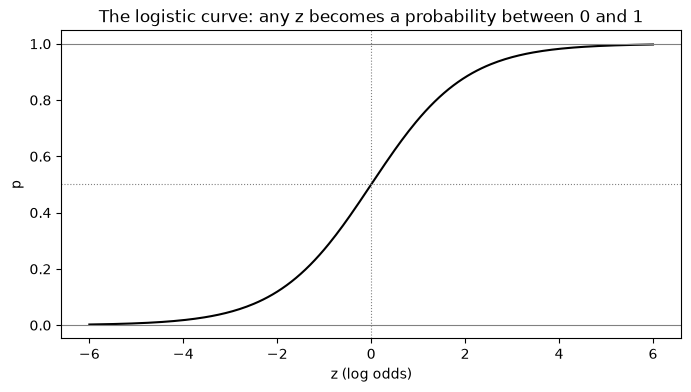

In [10]:
import matplotlib.pyplot as plt

# the logistic curve, written with numpy: exp works on a whole array at once
z = np.array([-4.0, -2.0, 0.0, 2.0, 4.0])
print(pd.DataFrame({"z": z, "p = 1 / (1 + exp(-z))": (1 / (1 + np.exp(-z))).round(4)}).to_string(index=False))

z_grid = np.linspace(-6, 6, 241)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(z_grid, 1 / (1 + np.exp(-z_grid)), color="black")
ax.axhline(0, color="grey", linewidth=0.8)
ax.axhline(1, color="grey", linewidth=0.8)
ax.axhline(0.5, color="grey", linewidth=0.8, linestyle=":")
ax.axvline(0, color="grey", linewidth=0.8, linestyle=":")
ax.set_title("The logistic curve: any z becomes a probability between 0 and 1")
ax.set_xlabel("z (log odds)")
ax.set_ylabel("p")
plt.show()

* z = 2 gives 0.8808 and z = -2 gives 0.1192: the curve is symmetric around 0.5. The S shape is what a straight line cannot do: it flattens at both ends instead of crossing 0 and 1.
* The axis is labelled *log odds*. Section 6.3 says why: z is the log of the odds.

## 6.3 Probability, Odds, and Log Odds

Three ways to say the same thing about an event:

| Name | Formula | Range | A default rate of 0.20 |
| --- | --- | --- | --- |
| Probability | p | 0 to 1 | 0.20 |
| Odds | p / (1 - p) | 0 to infinity | 0.25: one default for every four accounts that did not |
| Log odds | ln(p / (1 - p)) | minus to plus infinity | -1.3863 |

Odds are a desk word already: "four to one against". Log odds can take any value, so a straight line can be fitted to them, and the logistic curve is exactly the way back from log odds to a probability.

Q. On the training rows, what are the default rate, the odds, and the log odds for each `PAY_0` code?

In [11]:
# accounts and defaults for each code, on the training rows only
by_code = y_train.groupby(X_train["PAY_0"]).agg(accounts="size", defaults="sum")
by_code["default_rate"] = by_code["defaults"] / by_code["accounts"]
# odds: defaults per account that did not default; log odds: the natural log of the odds
by_code["odds"] = by_code["default_rate"] / (1 - by_code["default_rate"])
by_code["log_odds"] = np.log(by_code["odds"])
by_code.round(4)

,accounts,defaults,default_rate,odds,log_odds
PAY_0,,,,,
-2,1620,202,0.1247,0.1425,-1.9487
-1,3419,565,0.1653,0.1980,-1.6197
0,8807,1113,0.1264,0.1447,-1.9334
1,2269,780,0.3438,0.5238,-0.6466
2,1618,1125,0.6953,2.2819,0.8250
3,188,148,0.7872,3.7000,1.3083
4,43,28,0.6512,1.8667,0.6242
5,13,6,0.4615,0.8571,-0.1542
6,10,6,0.6000,1.5000,0.4055


* Code 2, a payment delay of two months: 1,125 defaults among 1,618 accounts, a rate of 0.6953 and odds of 2.28, about 2.3 defaults for every account that did not. Code 1: odds of 0.52.
* The log odds rise from code 0 to code 3, but not from code -2 to 0. The documented code -1, "pay duly", has the highest rate of the three (0.1653, against 0.1247 for -2 and 0.1264 for 0, the two undocumented codes). A model that uses `PAY_0` as one number assumes one step up the codes always moves the log odds by the same amount. These rates say that is only roughly true.
* Codes 4, 5, 6, 7, 8 hold 43, 13, 10, 7, 6 accounts. A rate on a handful of accounts moves a long way when one account changes, so those rows are read with their counts, as notebook 16 read every rate.

Q. Add the two functions that move between these scales to `mlkit.py`: `logistic_probability` turns log odds into a probability, and `odds_ratios` turns a coefficient into the factor its odds multiply by.

Read the two docstrings before you run the cell. Section 6.4 explains what an odds ratio is.

In [12]:
%%writefile -a mlkit.py


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability

Appending to mlkit.py


* `logistic_probability` is the curve of section 6.2. It returns a float for a number and an array for an array, so it works on one account or on thousands.
* `odds_ratios` leaves out the intercept by name, whether statsmodels calls it `const` or a table calls it `intercept`, because exp of the intercept is not a ratio of anything.

Q. Add the first two tests: hand values for the curve, and odds ratios that are worked out on paper.

In [13]:
%%writefile -a test_mlkit.py


from sklearn.linear_model import LogisticRegression

CARD_TARGET = "default payment next month"


def read_card() -> pd.DataFrame:
    """The 30,000 UCI card accounts, with LIMIT_BAL also in units of 10,000 NT dollars."""
    card = pd.read_csv(HERE / "credit_card_default.csv")
    card["LIMIT_BAL_10k"] = card["LIMIT_BAL"] / 10_000
    return card


def test_logistic_probability_hand_values():
    assert mlkit.logistic_probability(0.0) == pytest.approx(0.5, abs=1e-12)
    # log-odds of ln 3 are odds of 3 to 1, a probability of 0.75
    assert mlkit.logistic_probability(np.log(3)) == pytest.approx(0.75, abs=1e-12)
    probabilities = mlkit.logistic_probability(np.array([-np.log(3), 0.0]))
    assert probabilities == pytest.approx([0.25, 0.5], abs=1e-12)


def test_odds_ratios_exp():
    coefficients = pd.Series({"const": -1.4, "PAY_0": np.log(2.0), "LIMIT_BAL_10k": 0.0})
    ratios = mlkit.odds_ratios(coefficients)
    assert list(ratios.index) == ["PAY_0", "LIMIT_BAL_10k"]
    assert ratios["PAY_0"] == pytest.approx(2.0, abs=1e-12)
    assert ratios["LIMIT_BAL_10k"] == pytest.approx(1.0, abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.odds_ratios(pd.Series({"const": 1.0}))

Appending to test_mlkit.py


* `read_card` loads the card file the way this notebook did, plus the limit in units of 10,000 NT dollars, which section 6.4 uses. `log(3)` makes a good hand value: log odds of ln 3 are odds of 3 to 1, a probability of 0.75.

Q. Reload the module and run the tests.

In [14]:
# the file changed, so reload before using the new functions
importlib.reload(mlkit)
print(f"new in mlkit: {[name for name in ('odds_ratios', 'logistic_probability') if hasattr(mlkit, name)]}")

new in mlkit: ['odds_ratios', 'logistic_probability']


In [15]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_mlkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

......................                                                   [100%]
22 passed in 1.98s



* `22 passed`: the 20 tests from week 1 and today's first 2.

Q. Does `logistic_probability` turn the log odds in the table back into the default rates?

In [16]:
# from log odds back to a probability: the curve undoes the log of the odds
back = mlkit.logistic_probability(by_code["log_odds"].to_numpy())
print(f"back to the default rates, every code within 1e-12: {np.allclose(back, by_code['default_rate'], rtol=0, atol=1e-12)}")

back to the default rates, every code within 1e-12: True


* The same rates. Probability, odds, and log odds are one number on three scales, and the curve is the bridge from the last back to the first.

## 6.4 A Logistic Regression with statsmodels

A **logistic regression** fits log odds = b0 + b1 x1 + ... by maximum likelihood: it chooses the coefficients that make the outcomes in the training rows as likely as possible. statsmodels' `Logit` fits it with no penalty and reports standard errors, as `OLS` did in week 1; the course uses it to read coefficients.

Q. Fit a logistic regression of default on `PAY_0` on the training rows, and draw it beside the straight line of section 6.1.

const   -1.4185
PAY_0    0.7702


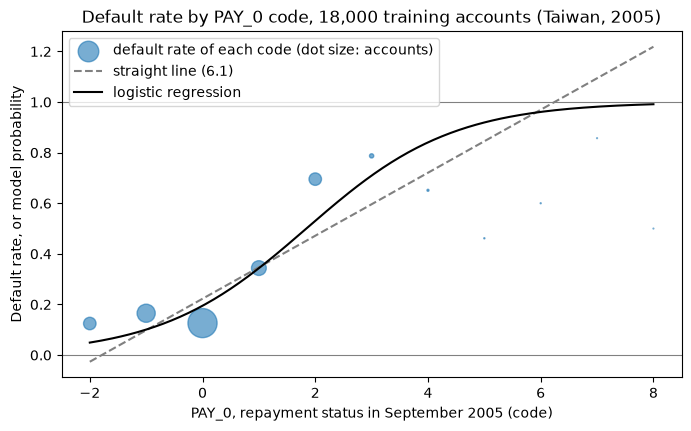

In [17]:
import statsmodels.api as sm

# add_constant adds the intercept column, named const, as in week 1
logit_pay0 = sm.Logit(y_train, sm.add_constant(X_train[["PAY_0"]])).fit(disp=0)
print(logit_pay0.params.round(4).to_string())

codes = np.linspace(-2, 8, 201)
fig, ax = plt.subplots(figsize=(8, 4.5))
# the training default rate of each code, each dot sized by its number of accounts
ax.scatter(by_code.index, by_code["default_rate"], s=by_code["accounts"] / 20, alpha=0.6,
           label="default rate of each code (dot size: accounts)")
ax.plot(codes, line.intercept_ + line.coef_[0] * codes, color="grey", linestyle="--", label="straight line (6.1)")
ax.plot(codes, mlkit.logistic_probability(logit_pay0.params["const"] + logit_pay0.params["PAY_0"] * codes),
        color="black", label="logistic regression")
ax.axhline(0, color="grey", linewidth=0.8)
ax.axhline(1, color="grey", linewidth=0.8)
ax.set_title("Default rate by PAY_0 code, 18,000 training accounts (Taiwan, 2005)")
ax.set_xlabel("PAY_0, repayment status in September 2005 (code)")
ax.set_ylabel("Default rate, or model probability")
ax.legend(loc="upper left")
plt.show()

* The fitted log odds are -1.4185 + 0.7702 x `PAY_0`. Through the curve, that stays between 0 and 1 at every code, where the straight line leaves at both ends.
* Neither model follows the dots at codes -2 to 0, the step this file shows between code 0 and code 1, or the thin codes from 4 up: both use the codes as evenly spaced numbers.

Q. Add the credit limit, in units of 10,000 NT dollars. Read each coefficient as an odds ratio, with its interval.

In [18]:
# the limit in units of 10,000 NT dollars, so one unit is a size a desk reads easily
X_train_2 = X_train[["PAY_0"]].assign(LIMIT_BAL_10k=X_train["LIMIT_BAL"] / 10_000)
logit_2 = sm.Logit(y_train, sm.add_constant(X_train_2)).fit(disp=0)

# exp turns a coefficient in log odds into an odds ratio; exp of each end of the interval gives the ratio's interval
interval = np.exp(logit_2.conf_int(alpha=0.05))
table_2 = pd.DataFrame({
    "coefficient (log odds)": logit_2.params,
    "standard error": logit_2.bse,
    "p-value": ["< 0.001" if p < 0.001 else f"{p:.3g}" for p in logit_2.pvalues],
    "odds ratio": mlkit.odds_ratios(logit_2.params),
    "odds ratio, 95% low": interval[0].drop("const"),
    "odds ratio, 95% high": interval[1].drop("const"),
}).reindex(["const", "PAY_0", "LIMIT_BAL_10k"])
# the constant has no odds ratio, so its last three cells are empty (NaN)
table_2.round(4)

,coefficient (log odds),standard error,p-value,odds ratio,"odds ratio, 95% low","odds ratio, 95% high"
const,-1.1026,0.0323,< 0.001,NaN,NaN,NaN
PAY_0,0.7213,0.0192,< 0.001,2.0571,1.9812,2.1359
LIMIT_BAL_10k,-0.0203,0.0017,< 0.001,0.9799,0.9766,0.9832


How to read the two odds ratios. Each is the factor by which the **odds** of default multiply for one more unit of that feature, **the other feature held fixed**, in this file:

* `PAY_0`: **2.0571 per step up the codes**. Two accounts with the same limit, one code apart, have odds of default about twice as high for the higher code. The interval runs from 1.9812 to 2.1359. "Per step" leans on the modelling choice of section 6.3: the codes are used as evenly spaced numbers.
* `LIMIT_BAL_10k`: **0.9799 per 10,000 NT dollars of credit limit**, about 2.0 percent lower odds for each 10,000 NT dollars more, at the same `PAY_0` code.
* **The unit decides the number.** Per single NT dollar the same coefficient gives exp(-0.020327 / 10,000) = 0.999998, which looks like no association at all. Always state the unit beside an odds ratio.
* The constant is left out of the odds ratios: exp(-1.1026) = 0.3320 is the odds for an account with code 0 and a limit of zero, which no account has. It is a starting point, not a ratio.
* The odds ratio of `PAY_0` fell from 2.1602 alone to 2.0571 with the limit beside it: accounts with higher codes tend to have lower limits in this file, so part of what `PAY_0` carried alone is now carried by the limit.

**An odds ratio is an association in this dataset, not a cause.** It does not say that a lower limit leads to default, or that moving an account's code would change its outcome. The lender set each limit for reasons the file does not record. And "odds twice as high" is not "probability twice as high": an account at a probability of 0.5 has odds of 1, and doubling them gives odds of 2, a probability of 0.67.

Q. What is the model probability of default in this file for three made-up accounts, each with a limit of 100,000 NT dollars and `PAY_0` of -1, 0, and 2?

In [19]:
# three made-up accounts: the features in the model's units
examples = pd.DataFrame({"PAY_0": [-1, 0, 2], "LIMIT_BAL_10k": [10.0, 10.0, 10.0]})
# log odds by hand: the intercept plus each coefficient times its feature, then the curve
log_odds = logit_2.params["const"] + examples @ logit_2.params[["PAY_0", "LIMIT_BAL_10k"]]
examples["model probability"] = mlkit.logistic_probability(log_odds)
examples["odds"] = examples["model probability"] / (1 - examples["model probability"])

# statsmodels' own output for the same rows must agree
statsmodels_output = logit_2.predict(sm.add_constant(examples[["PAY_0", "LIMIT_BAL_10k"]], has_constant="add"))
print(f"equal to statsmodels within 1e-12: {np.allclose(examples['model probability'], statsmodels_output, rtol=0, atol=1e-12)}")
examples.round(4)

equal to statsmodels within 1e-12: True


,PAY_0,LIMIT_BAL_10k,model probability,odds
0,-1,10.0,0.1164,0.1317
1,0,10.0,0.2132,0.2709
2,2,10.0,0.5341,1.1465


* These are **model probabilities of default in this file**: what the fitted curve gives an account with these two values, and nothing else. For `PAY_0` of 2 it is 0.5341.
* From code 0 to code 2 is two steps, so the odds multiply by 2.0571 twice: 0.2709 x 2.0571 x 2.0571 = 1.1465. The probability does not double twice; the curve bends.

## 6.5 scikit-learn's LogisticRegression, and a Pipeline

scikit-learn's `LogisticRegression` is the one used in pipelines and in every tutorial. Three things about it matter today:

1. **It has a penalty by default.** Like ridge on day 5, it shrinks the coefficients a little, with strength set by `C`: the default is `C=1.0`, and a smaller `C` shrinks more. `C=np.inf` turns the penalty off, which is the fit statsmodels makes.
2. **`penalty=` is never used in this course.** scikit-learn 1.8 deprecated that argument, and it is due to be removed in 1.10. `C` alone says how much to shrink.
3. **`tol=1e-8` when comparing with statsmodels.** The solver stops when its steps get smaller than `tol`. With the default, `1e-4`, it can stop a few ten-thousandths away from statsmodels' answer, which is outside the course's 1e-4 tolerance; a tighter `tol` lets it finish. A pipeline that is not compared with statsmodels keeps the default.

Q. Fit the section 6.4 model with `LogisticRegression(C=np.inf, tol=1e-8, max_iter=1000)`. Does it give statsmodels' coefficients?

In [20]:
from sklearn.linear_model import LogisticRegression

# no penalty (C=np.inf), and a tight stopping rule so the solver reaches statsmodels' answer
no_penalty = LogisticRegression(C=np.inf, tol=1e-8, max_iter=1000).fit(X_train_2, y_train)
# with the default penalty, C=1.0
default_penalty = LogisticRegression().fit(X_train_2, y_train)

compare = pd.DataFrame({
    "statsmodels Logit": logit_2.params.to_numpy(),
    "C=np.inf": np.r_[no_penalty.intercept_, no_penalty.coef_[0]],
    "C=1.0 (default)": np.r_[default_penalty.intercept_, default_penalty.coef_[0]],
}, index=["intercept", "PAY_0", "LIMIT_BAL_10k"])
compare["C=np.inf within 1e-4"] = (compare["statsmodels Logit"] - compare["C=np.inf"]).abs() < 1e-4
compare.round(4)

,statsmodels Logit,C=np.inf,C=1.0 (default),C=np.inf within 1e-4
intercept,-1.1026,-1.1026,-1.1025,True
PAY_0,0.7213,0.7213,0.7210,True
LIMIT_BAL_10k,-0.0203,-0.0203,-0.0203,True


* With the penalty off, scikit-learn and statsmodels agree within the course's tolerance: one model, two libraries. scikit-learn keeps the intercept in `intercept_` and the slopes in `coef_`, one row per class it models, so `coef_[0]` is the row for default.
* With the default `C=1.0` the coefficients move only in the fourth decimal: 18,000 rows and two features leave the penalty little to do. With many features, few rows, or features on very different scales, it does much more, which is why scaling comes before a penalised model.

Q. Add the last two tests: statsmodels against Excel Solver's results on all 30,000 accounts (from the course's Excel reference file), and scikit-learn with `C=np.inf` against statsmodels.

In [21]:
%%writefile -a test_mlkit.py


@pytest.mark.parametrize("model, features", [
    ("d06_logit_default_on_pay0", ["PAY_0"]),
    ("d06_logit_default_on_pay0_limit10k", ["PAY_0", "LIMIT_BAL_10k"]),
])
def test_logit_matches_excel_solver_reference(model, features):
    card = read_card()
    logit = sm.Logit(card[CARD_TARGET], sm.add_constant(card[features]))
    fit = logit.fit(disp=0)
    # Excel Solver, non-negative box off, maximising the summed log-likelihood column
    solver = pd.Series({name: excel(f"{model}:coef_{name}") for name in ["const"] + features})
    for name in solver.index:
        assert fit.params[name] == pytest.approx(solver[name], abs=1e-4), name
    # the log-likelihood Excel summed, at Excel's own coefficients
    assert logit.loglike(solver[fit.params.index].to_numpy()) == pytest.approx(excel(f"{model}:loglik"), abs=1e-6)
    # Excel: =EXP(coef) as an odds ratio
    for name, ratio in mlkit.odds_ratios(solver).items():
        assert ratio == pytest.approx(excel(f"{model}:odds_ratio_{name}"), abs=1e-12)


@pytest.mark.parametrize("features", [["PAY_0"], ["PAY_0", "LIMIT_BAL_10k"]])
def test_sklearn_cinf_matches_statsmodels(features):
    card = read_card()
    fit = sm.Logit(card[CARD_TARGET], sm.add_constant(card[features])).fit(disp=0)
    # C=np.inf switches the default L2 penalty off; penalty= is never used (deprecated in scikit-learn 1.8).
    # tol=1e-8: with the default tol=1e-4 the solver stops 2.2e-4 away on PAY_0 alone
    model = LogisticRegression(C=np.inf, tol=1e-8, max_iter=1000).fit(card[features], card[CARD_TARGET])
    assert model.intercept_[0] == pytest.approx(fit.params["const"], abs=1e-4)
    for name, value in zip(features, model.coef_[0]):
        assert value == pytest.approx(fit.params[name], abs=1e-4), name

Appending to test_mlkit.py


* `parametrize` runs each test twice, once for `PAY_0` alone and once with the limit, so the two functions count as four tests. The comments carry the two rules of this section: `C=np.inf` with no `penalty=`, and why `tol=1e-8` is there.

In [22]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_mlkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

..........................                                               [100%]
26 passed in 2.33s



* `26 passed`. The Excel test reads Solver's coefficients, Excel's summed log-likelihood, and the `=EXP` odds ratios from `course4_excel_reference.csv`, so the module now pins the logistic fit to Excel as well as to statsmodels.

Q. Put a scaler and the model in one `Pipeline`, as on day 5. What do the coefficients mean now?

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# one fit call fits the scaler on the training rows, then the model on the scaled training rows
pipe_2 = Pipeline([("scale", StandardScaler()),
                   ("model", LogisticRegression(C=np.inf, tol=1e-8, max_iter=1000))])
pipe_2.fit(X_train_2, y_train)

scaler = pipe_2.named_steps["scale"]
per_sd = pipe_2.named_steps["model"].coef_[0]
print(f"the scaler's means are the training rows' means: {np.allclose(scaler.mean_, X_train_2.mean(), rtol=0, atol=1e-9)}")
pd.DataFrame({
    "standard deviation (training rows)": scaler.scale_,
    "coefficient per standard deviation": per_sd,
    "divided by the standard deviation": per_sd / scaler.scale_,
    "statsmodels, per unit": logit_2.params[["PAY_0", "LIMIT_BAL_10k"]].to_numpy(),
}, index=["PAY_0", "LIMIT_BAL_10k"]).round(4)

the scaler's means are the training rows' means: True


,standard deviation (training rows),coefficient per standard deviation,divided by the standard deviation,"statsmodels, per unit"
PAY_0,1.1163,0.8052,0.7213,0.7213
LIMIT_BAL_10k,12.9563,-0.2634,-0.0203,-0.0203


* After `StandardScaler`, one unit of each feature is one standard deviation of the training rows: 1.1163 codes for `PAY_0` and 12.9563 units of 10,000 NT dollars for the limit. So the coefficients are **per standard deviation**: 0.8052 and -0.2634.
* Divide each by its standard deviation and you are back at statsmodels' coefficients per unit. Without a penalty, scaling changes only the unit a coefficient is stated in, not the model.
* The pipeline is the course's rule from today: **every preprocessing step lives inside a pipeline**, so it is fitted on the training rows in the same `.fit` as the model, and applied unchanged to any other rows. The scaler's means are the training rows' means, not the file's.

## 6.6 All 19 Columns, Scaled

Q. Fit a logistic regression on all 19 features inside a pipeline with a scaler, with scikit-learn's default penalty. Which coefficients are largest?

In [24]:
# the week's standard model: scaled features, the default penalty C=1.0, enough iterations to converge
pipe_19 = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
pipe_19.fit(X_train, y_train)

# day 5's function labels each coefficient with its feature name
coefficients = mlkit.named_coefficients(pipe_19)
table_19 = pd.DataFrame({
    "one standard deviation": pipe_19.named_steps["scale"].scale_,
    "coefficient per standard deviation": coefficients,
    "odds ratio per standard deviation": mlkit.odds_ratios(coefficients),
}, index=coefficients.index)
table_19.reindex(coefficients.abs().sort_values(ascending=False).index).round(4)

,one standard deviation,coefficient per standard deviation,odds ratio per standard deviation
PAY_0,1.1163,0.6890,1.9917
BILL_AMT1,72360.3884,-0.3396,0.7121
PAY_AMT2,20214.4521,-0.2226,0.8005
PAY_AMT1,16793.5192,-0.1839,0.8321
LIMIT_BAL,129563.1562,-0.1049,0.9004
PAY_3,1.1970,0.1047,1.1104
BILL_AMT3,67942.5735,0.1017,1.1070
PAY_2,1.1967,0.0828,1.0863
PAY_AMT5,14764.1347,-0.0755,0.9273
BILL_AMT4,63825.2629,0.0711,1.0736


* With scaled features every coefficient is **per standard deviation of that feature on the training rows**, so they are on one footing: the first column says how big a standard deviation is, in codes or NT dollars. `PAY_0` has the largest, an odds ratio of 1.9917 per standard deviation (1.1163 codes), then `BILL_AMT1` and `PAY_AMT2`.
* Look at the bills. `BILL_AMT1` has an odds ratio below 1 (0.7121) and `BILL_AMT3` above 1 (1.1070). The six bills move together (the correlation of `BILL_AMT1` and `BILL_AMT2` on the training rows is 0.9511), and "holding the other 18 fixed" asks what one bill does while the next month's bill stays put, which few accounts ever do. With columns that move together the model splits one association among them, and the signs can point opposite ways. Day 3 met the same thing as multicollinearity.
* So this table is **not a ranking of what matters**, and no coefficient in it is a cause. Day 9 meets feature importance and what it does and does not say.

Q. What does the model give the validation accounts?

6,000 validation accounts: model probability from 0.0000 to 0.9935, mean 0.2187; actual default rate 0.2212


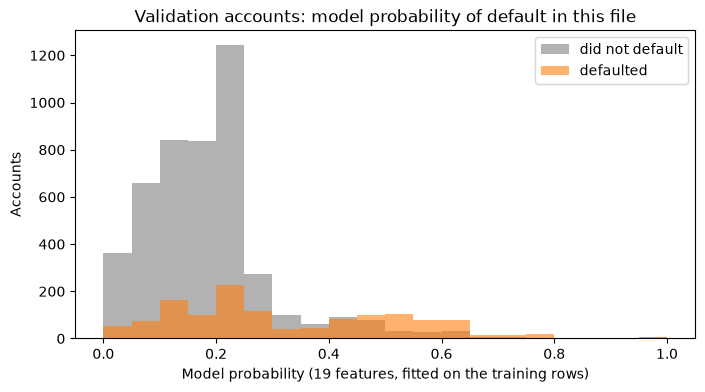

In [25]:
# the model probability of default in this file, for each validation account: column 1 of predict_proba is class 1
proba_valid = pipe_19.predict_proba(X_valid)[:, 1]
print(f"{len(proba_valid):,} validation accounts: model probability from {proba_valid.min():.4f} to {proba_valid.max():.4f}, "
      f"mean {proba_valid.mean():.4f}; actual default rate {y_valid.mean():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 1, 21)
ax.hist(proba_valid[y_valid.to_numpy() == 0], bins=bins, alpha=0.6, color="grey", label="did not default")
ax.hist(proba_valid[y_valid.to_numpy() == 1], bins=bins, alpha=0.6, color="tab:orange", label="defaulted")
ax.set_title("Validation accounts: model probability of default in this file")
ax.set_xlabel("Model probability (19 features, fitted on the training rows)")
ax.set_ylabel("Accounts")
ax.legend()
plt.show()

* `predict_proba` returns one column per class; column 1 is the model probability of default. Across the validation accounts its mean is 0.2187, close to the actual rate of 0.2212.
* The two groups overlap heavily: 76% of the validation accounts that defaulted get a probability below 0.5. A probability is not yet a yes or no; day 7 turns it into a flag at a threshold and counts what that catches and misses.

Q. By `PAY_0` code, how does the model's mean probability compare with the actual default rate on the validation rows?

In [26]:
# for each code: accounts, the actual default rate, and the model's mean probability, on the validation rows
by_code_valid = pd.DataFrame({"PAY_0": X_valid["PAY_0"], "default": y_valid, "model probability": proba_valid})
by_code_valid.groupby("PAY_0").agg(accounts=("default", "size"), default_rate=("default", "mean"),
                                   mean_model_probability=("model probability", "mean")).round(4)

,accounts,default_rate,mean_model_probability
PAY_0,,,
-2,578,0.1332,0.0468
-1,1108,0.1697,0.1063
0,2974,0.1328,0.1931
1,731,0.3434,0.3437
2,520,0.6885,0.5240
3,57,0.7018,0.7222
4,15,0.6667,0.7949
5,5,0.4000,0.9285
7,2,0.5000,0.9797


* At code 1 the two agree closely (0.3434 against 0.3437). At code -2 the model's mean is 0.0468 where 0.1332 of the 578 accounts defaulted, and at code 0 it is 0.1931 against 0.1328. That is the modelling choice of section 6.3 showing: one coefficient on `PAY_0` puts code -2 two even steps below code 0, which these rates do not show.
* The other columns move the probabilities too, so this is not a test of the model. It says where a model with one straight line in the log odds fits this file's groups loosely. Day 8 draws a calibration curve for the whole range.

## 6.7 What the Model's Probability Is, and What It Is Not

For the card file, a model's output gets one of these names, and only these:

| Allowed | What it means |
| --- | --- |
| model probability of default in this file | The fitted curve's value for an account with these 19 values |
| flagged at threshold t (day 7) | The probability is at least t |
| the model's score | The same probability, when only its order matters (day 8) |

It is never called a credit decision, an approval, a decline, a lending policy, or a risk grade for a real person.

What the probability **is**: a number between 0 and 1 from a curve fitted to 18,000 accounts in Taiwan in 2005, with 19 columns, used as the file records them. What it **is not**:

* Not a statement about any person. Two accounts with the same 19 values get the same number, whatever else is true of them.
* Not a cause. An odds ratio is an association in this dataset; nothing here says what would happen if a limit or a payment changed.
* Not a statement about another market or year. Consumer credit in Taiwan in 2005 differs from US credit today.
* Not checked yet. Today reported no error measure for a classifier. Days 7 and 8 add them, on the validation rows; day 10 opens the test rows once.

Notebook 16 said it of every group rate in this file, and it holds for every model on it: "Differences between groups in this file do not explain themselves, and they are not a basis for treating people differently."

## Excel Side by Side

Excel has no worksheet function for a logistic regression. It has the pieces: a probability formula, a log-likelihood column, a sum, and **Solver**, the optimiser that comes with desktop Excel, to choose the coefficients that make the sum as large as possible. Every formula below was typed into Excel by script on the 18,000 training rows, pasted from this notebook's split (Excel 16.0 build 20430, 2026-10-04).

The sheet `train` holds the default flag (0 or 1) in A, `PAY_0` in B, `LIMIT_BAL` in C, and `=C2/10000` in D, filled down, for the limit per 10,000 NT dollars; headers in row 1, accounts in rows 2 to 18001. The coefficients sit in three cells, K1 (intercept), K2 (`PAY_0`), and K3 (limit), starting at 0. The model on `PAY_0` alone uses the same layout in columns E and F, with its two coefficients in H1:H2 and its sum in H3.

| Job | Python | Excel |
| --- | --- | --- |
| Model probability of each account | `mlkit.logistic_probability(z)` | `=1/(1+EXP(-($K$1+$K$2*B2+$K$3*D2)))` in I2, filled down |
| Its log-likelihood | the term `Logit` maximises | `=A2*LN(I2)+(1-A2)*LN(1-I2)` in J2, filled down |
| The sum to maximise | `logit_2.llf` | `=SUM(J2:J18001)` in K4 |
| The fit | `sm.Logit(...).fit()` | Solver: maximise K4 by changing K1:K3, GRG Nonlinear, with "Make Unconstrained Variables Non-Negative" **unticked** |
| Odds ratios | `mlkit.odds_ratios(logit_2.params)` | `=EXP(K2)` and `=EXP(K3)` |

**The probability column.** `$K$1+$K$2*B2+$K$3*D2` is the log odds, the straight line of section 6.4 written out; `1/(1+EXP(-...))` is the logistic curve. The dollar signs lock the three coefficient cells, so filling down changes only the row.

**The log-likelihood column.** For an account that defaulted (A2 = 1) the formula reduces to `LN(I2)`, the log of the probability the model gave a default; for one that did not, to `LN(1-I2)`. The sum over all rows is largest when the model gives high probabilities to the defaults and low ones to the others. That sum is what statsmodels maximises, and typed at statsmodels' coefficients Excel's sum matched statsmodels' log-likelihood within 1e-6.

**Solver, and the box to untick.** Solver's dialog has a box, "Make Unconstrained Variables Non-Negative", that is **ticked by default**. Here the intercept and the limit's coefficient must be negative. Run with the default options on the `PAY_0` model, Solver kept the intercept at exactly 0, moved the slope to 0.5748, reached a log-likelihood of -11,706.18 against -8,495.88 for the real fit, and **still reported that it had found a solution** (return code 0). Nothing on the screen says the answer is wrong. Untick the box, and Solver found statsmodels' coefficients for both models: -1.1026, 0.7213, and -0.0203 for this one. The script also set the options written out in the course's Excel reference file: central derivatives and a convergence of 1e-10.

The module's test `test_logit_matches_excel_solver_reference` checks the same two fits on all 30,000 accounts against Excel's results in `course4_excel_reference.csv`.

In [27]:
# Excel's Solver results on the 18,000 training rows, from the day's Excel check, beside statsmodels on the same rows
excel_solver = {
    "PAY_0 alone": [-1.4185479138773345, 0.7702122801658935],
    "PAY_0 and LIMIT_BAL_10k": [-1.1026069518998731, 0.7212926658870555, -0.02032736050507467],
}
excel_loglik = {"PAY_0 alone": -8495.882758662754, "PAY_0 and LIMIT_BAL_10k": -8420.214724287185}
excel_odds_ratios = [2.057090623576002, 0.979877847489704]   # =EXP(K2) and =EXP(K3)

rows = []
for name, fit in [("PAY_0 alone", logit_pay0), ("PAY_0 and LIMIT_BAL_10k", logit_2)]:
    solver = np.array(excel_solver[name])
    rows.append({
        "model": name,
        "coefficients within 1e-4 of statsmodels": bool(np.all(np.abs(solver - fit.params.to_numpy()) < 1e-4)),
        # statsmodels' log-likelihood at Excel's own coefficients, against Excel's summed column
        "log-likelihood within 1e-6": abs(fit.model.loglike(solver) - excel_loglik[name]) < 1e-6,
    })
print(pd.DataFrame(rows).to_string(index=False))
ratios = mlkit.odds_ratios(pd.Series(excel_solver["PAY_0 and LIMIT_BAL_10k"], index=["const", "PAY_0", "LIMIT_BAL_10k"]))
print(f"=EXP(...) equal to odds_ratios within 1e-12: {np.allclose(ratios, excel_odds_ratios, rtol=0, atol=1e-12)}")

                  model  coefficients within 1e-4 of statsmodels  log-likelihood within 1e-6
            PAY_0 alone                                     True                        True
PAY_0 and LIMIT_BAL_10k                                     True                        True
=EXP(...) equal to odds_ratios within 1e-12: True


* Both fits match, and so do the odds ratios. Excel can fit a logistic regression with Solver; it takes three columns, a sum, and one unticked box.
* With the box left ticked the same steps give an intercept of 0 and a "solution". When an optimiser reports success, check the answer against something you trust, as this cell does.

## Save the Day with Git

Today's work folder is new, so it gets its own repository, as on day 1.

Q. Make the work folder a repository.

In [28]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1

Q. Is Git working in the work folder, and only there?

In [29]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course4_06_vgb0r11l and nowhere else


Q. Tell Git which files never to track, as on day 1.

In [30]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx

Writing .gitignore


Q. Commit the module, its tests, and `.gitignore`. The four data files are copies of the course's files, so they stay out.

In [31]:
!git -C "{work}" add .gitignore mlkit.py test_mlkit.py
!git -C "{work}" commit -q -m "mlkit through day 6: odds_ratios and logistic_probability, with their tests"
!git -C "{work}" log --oneline

0d87b81 mlkit through day 6: odds_ratios and logistic_probability, with their tests


Q. What did that commit hold? `git show --stat HEAD` shows the last commit's message and, for each file, how many lines it added or removed.

In [32]:
# HEAD is the last commit; --stat lists its files and a count of the lines added (+) and removed (-)
!git -C "{work}" show --stat HEAD

commit 0d87b8143b2a4c2b1e8b1f7fd7d46aa529d1dfeb
Author: Course Student <student@example.com>
Date:   Sun Oct 4 22:39:04 2026 -0400

    mlkit through day 6: odds_ratios and logistic_probability, with their tests

 .gitignore    |   3 +
 mlkit.py      | 242 ++++++++++++++++++++++++++++++++++++++++++
 test_mlkit.py | 335 ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
 3 files changed, 580 insertions(+)


* Three files, every line new, because this repository started today: 242 lines of `mlkit.py` and 335 of `test_mlkit.py`. In your own `my_bondmath` folder the same command after Bring It Home shows only today's additions, because the earlier days are already committed there.
* `--stat` is the quickest answer to "what did this commit touch?" before you read the whole change with `git show HEAD`.

## Bring It Home

Add today's two functions and four tests to your own `my_bondmath` folder. Open a PowerShell terminal in VS Code.

**Step 1.** Activate the course's `.venv`, go to your folder, and copy in the card file, which today's tests read.

```powershell
Set-Location "$HOME\projects\python-fixed-income"
.\.venv\Scripts\Activate.ps1
Set-Location "$HOME\projects\my_bondmath"
Copy-Item "$HOME\projects\python-fixed-income\data\credit_card_default.csv" .
code mlkit.py
code test_mlkit.py
```

**Step 2.** Paste the code of the `%%writefile -a mlkit.py` cell (section 6.3), without its first line, at the end of `mlkit.py`. Paste the two `%%writefile -a test_mlkit.py` cells (sections 6.3 and 6.5), without their first lines, at the end of `test_mlkit.py`, one after the other. Save both.

**Step 3.** Run the tests.

```powershell
python -m pytest -q test_mlkit.py
```

The last line says `26 passed`.

**Step 4.** Look at the change, then commit the code only. The card file is a copy of the course's file, so it is never committed here.

```powershell
git diff --stat
git add mlkit.py test_mlkit.py
git commit -m "mlkit through day 6: odds_ratios and logistic_probability, with their tests"
git show --stat HEAD
```

**In Colab**, download `mlkit.py` and `test_mlkit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Say why a straight line fails on a 0/1 outcome, and what the logistic curve does instead.
* Move between probability, odds, and log odds, with `logistic_probability` to come back from log odds.
* Fit a logistic regression with statsmodels and read each coefficient as an odds ratio with its unit, as an association in this file and not a cause.
* Fit the same model in scikit-learn: the default penalty, `C=np.inf`, `tol=1e-8` for a comparison, and no `penalty=`.
* Put the scaler inside a `Pipeline` and read coefficients per standard deviation.
* Name a model's output on the card file only with the allowed names.
* Fit a logistic regression in Excel with Solver, and spot the non-negative box.

Tomorrow, day 7, turns the probability into a flag at a threshold, counts what it catches and misses in a confusion matrix, and shows why a model that is right on most accounts can still catch no defaults.

## Exercises

The exercises use the same card file, the same split, and the training rows only: 30,000 real accounts in Taiwan in 2005 (UCI, CC BY 4.0), with the four person columns never used as features. Every answer describes this file; none is a statement about a person or a lending rule. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the card file, makes the week's split, fits section 6.4's model on the training rows, and defines `check`, a small function that marks your answers.

In [33]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

# the card file, the 19 features, and the week's split, as at the top of the notebook
card = pd.read_csv("credit_card_default.csv")
TARGET = "default payment next month"
PERSON_COLUMNS = ["SEX", "EDUCATION", "MARRIAGE", "AGE"]
FEATURES = [column for column in card.columns if column not in ["ID", TARGET] + PERSON_COLUMNS]
X_rest, X_test, y_rest, y_test = train_test_split(card[FEATURES], card[TARGET], test_size=0.2, stratify=card[TARGET],
                                                  random_state=SEED)
X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                      random_state=SEED)

# section 6.4's model: PAY_0 and the limit per 10,000 NT dollars, on the training rows
X_train_2 = X_train[["PAY_0"]].assign(LIMIT_BAL_10k=X_train["LIMIT_BAL"] / 10_000)
logit_2 = sm.Logit(y_train, sm.add_constant(X_train_2)).fit(disp=0)


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. `PAY_2` is the repayment status in August 2005, a month before `PAY_0`. Fit a logistic regression of default on `PAY_2` alone on the training rows with statsmodels. Store its coefficient in log odds in **ex1_coefficient** and its odds ratio per step up the codes in **ex1_odds_ratio**.

In [34]:
ex1_coefficient = ...
ex1_odds_ratio = ...

In [35]:
check("Exercise 1 the coefficient", ex1_coefficient, 0.519932297306084)
check("Exercise 1 the odds ratio", ex1_odds_ratio, 1.6819137757505906)

Exercise 1 the coefficient: not attempted yet
Exercise 1 the odds ratio: not attempted yet


### Exercise 2

Q. Section 6.4 read the limit's odds ratio per 10,000 NT dollars. Using `logit_2`, what is it per **50,000** NT dollars, holding `PAY_0` fixed? Store it in **ex2_odds_ratio_50k**.

In [36]:
ex2_odds_ratio_50k = ...

In [37]:
check("Exercise 2 the odds ratio per 50,000 NT dollars", ex2_odds_ratio_50k, 0.9033575637518404)

Exercise 2 the odds ratio per 50,000 NT dollars: not attempted yet


### Exercise 3

Q. Add a function to your module. `odds(p)` returns the odds p / (1 - p) of an event with probability p, and raises `ValueError` when p is below 0, or 1 or more. Write the docstring first, with the range of p. Then add `test_odds_hand_values`: 0.5 gives 1, 0.75 gives 3, 0.2 gives 0.25, `logistic_probability(log(odds(0.3)))` gives back 0.3, and 1.0 raises. Run pytest, reload the module, and store `mlkit.odds(y_train.mean())`, the odds of default on the training rows, in **ex3_training_odds**.

Write the function in the cell that starts with `%%writefile -a mlkit.py` and the test in the one that starts with `%%writefile -a test_mlkit.py`, and run each of those cells once.

In [38]:
%%writefile -a mlkit.py


# Exercise 3: write odds(p) below this line

Appending to mlkit.py


In [39]:
%%writefile -a test_mlkit.py


# Exercise 3: write test_odds_hand_values() below this line

Appending to test_mlkit.py


In [40]:
# run pytest, reload the module, then call your function
ex3_training_odds = ...

In [41]:
check("Exercise 3 the odds of default on the training rows", ex3_training_odds, 0.2840633471251248)

Exercise 3 the odds of default on the training rows: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that fits a logistic regression and returns its odds ratios, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Odds ratios of a logistic regression of default on the given features, fitted on the training rows.

    Fit: statsmodels Logit of y_train on X_train[features] with a constant, unpenalised.
    Returns: a Series with one odds ratio per feature: exp of its coefficient, the factor by which the odds
    of default multiply for one more unit of that feature, the other features fixed. No intercept.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns one number per feature, and contains one bug.

In [42]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def odds_ratio_table(X_train, y_train, features):
    """Odds ratios of a logistic regression of default on the given features, fitted on the training rows.

    Fit: statsmodels Logit of y_train on X_train[features] with a constant, unpenalised.
    Returns: a Series with one odds ratio per feature: exp of its coefficient, the factor by which the odds
    of default multiply for one more unit of that feature, the other features fixed. No intercept.
    """
    fit = sm.Logit(y_train, sm.add_constant(X_train[features])).fit(disp=0)
    # one odds ratio per feature, the intercept left out
    return fit.params.drop("const").rename("odds_ratio")

Q. Before you run the next cell: section 6.4 found odds of default about twice as high per step up the `PAY_0` codes. Will this function's `PAY_0` value be above 1 or below 1? Could any value it returns be below 0?

In [43]:
print(odds_ratio_table(X_train_2, y_train, ["PAY_0", "LIMIT_BAL_10k"]).round(4).to_string())

PAY_0            0.7213
LIMIT_BAL_10k   -0.0203


Q. Test the function against its docstring before you trust it.

In [44]:
# the test, written from the docstring before the code is trusted
ratios = odds_ratio_table(X_train_2, y_train, ["PAY_0", "LIMIT_BAL_10k"])
fit = sm.Logit(y_train, sm.add_constant(X_train_2)).fit(disp=0)

# 1. an odds ratio is exp of something, so it is above 0
assert (ratios > 0).all(), f"{int((ratios <= 0).sum())} odds ratio at or below 0: a coefficient in log odds, not an odds ratio"
# 2. each one is exp of statsmodels' coefficient: odds_ratios' formula, written out so the message stops in this cell
expected = np.exp(fit.params.drop("const"))
assert np.allclose(ratios, expected, rtol=0, atol=1e-12), "the values are not exp of the coefficients"
print("odds_ratio_table returns odds ratios")

AssertionError: 1 odds ratio at or below 0: a coefficient in log odds, not an odds ratio

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the fixed function's odds ratio for `PAY_0`, `odds_ratio_table(X_train_2, y_train, ["PAY_0", "LIMIT_BAL_10k"])["PAY_0"]`, in **ex4_pay0_odds_ratio**.

In [45]:
# fix the function above and run the test again, then store the answer
ex4_pay0_odds_ratio = ...

In [46]:
check("Exercise 4 the fixed function's odds ratio for PAY_0", ex4_pay0_odds_ratio, 2.0570903919202737)

Exercise 4 the fixed function's odds ratio for PAY_0: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```